In [1]:
import jax
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from coppuccino.hdr import compute_injection_hdr
import corner

%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_posterior.feather')
df_inj = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_injections.feather')

In [3]:
def wrap_polarization_angle(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wrap the polarization angle to be between 0 and pi.
    """
    theta = df["Polarization"].to_numpy().squeeze()
    wrapped = np.abs(np.angle(np.exp(1j * theta)))
    df["Polarization"] = wrapped
    return df

In [4]:
wrap_polarization_angle(df_inj)

,Name,Amplitude,Ecliptic Latitude,Ecliptic Longitude,Frequency,Frequency Derivative,Inclination,Initial Phase,Polarization,SNR,Detached
0,14243782.0,1.927624e-23,0.078460,1.481040,0.000915,7.268414e-19,2.497675,2.544726,1.028365,2.669257,1
1,5710781.0,2.924891e-23,0.655874,5.076941,0.000915,7.535848e-19,2.453736,0.818838,3.096193,3.769661,1
2,1897944.0,1.630765e-22,0.611744,5.401896,0.000915,1.771697e-18,2.575621,0.677613,1.332100,22.895463,1
3,20548331.0,4.310133e-23,-0.065086,4.660957,0.000915,3.480832e-18,1.182964,5.240223,1.564026,3.510039,1


In [5]:
binary_parameters = ['Frequency', 'Amplitude', 'Inclination',
                              'Initial Phase', 'Ecliptic Latitude',
                              'Ecliptic Longitude', 'Polarization',
                              'Frequency Derivative']

In [6]:
samples = df[binary_parameters].to_numpy()
injection_params = df_inj[binary_parameters].to_numpy()

In [7]:
import jax

In [8]:
hdrs, flow = compute_injection_hdr(samples, injection_params, return_flow=True)

 19%|█▉        | 75/400 [01:01<04:25,  1.22it/s, train=11.4, val=11.5 (Max patience reached)]


In [9]:
hdrs

array([1.     , 1.     , 0.99975, 1.     ])

In [10]:
injection_params[1]

array([9.14610105e-04, 2.92489066e-23, 2.45373608e+00, 8.18837623e-01,
       6.55873818e-01, 5.07694080e+00, 3.09619336e+00, 7.53584771e-19])

In [11]:
flow_samples, lp = flow.sample_and_log_prob(jax.random.key(40), (100_000,))

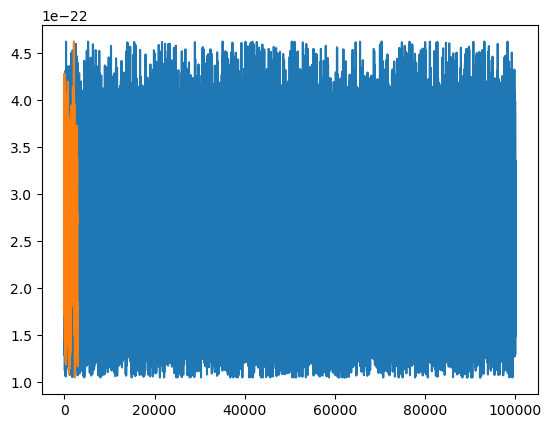

In [12]:
plt.plot(flow_samples[:, 1])
plt.plot(samples[:, 1])

(array([3.31626718e+20, 3.06439879e+20, 6.77246125e+20, 3.31346865e+21,
        3.31206938e+21, 5.23046698e+21, 6.27851935e+21, 6.27292227e+21,
        6.79345029e+21, 6.15538369e+21, 4.00050965e+21, 3.15954907e+21,
        3.21132202e+21, 4.03269284e+21, 4.34752833e+21, 3.72485369e+21,
        3.41561527e+21, 2.88389311e+21, 3.11897028e+21, 3.59752022e+21,
        3.50936629e+21, 5.41237193e+21, 4.61059087e+21, 3.96972574e+21,
        4.68755066e+21, 5.06255471e+21, 4.38390932e+21, 4.65816602e+21,
        3.13296296e+21, 4.38530859e+21, 2.98184193e+21, 2.19125503e+21,
        2.93146825e+21, 2.08211206e+21, 1.39087324e+21, 2.59704299e+21,
        1.71970142e+21, 9.71092585e+20, 1.58537161e+21, 6.84242470e+20,
        3.69406978e+20, 5.28923627e+20, 7.87788365e+20, 4.49165302e+20,
        1.62315187e+20, 1.37128348e+20, 9.37510132e+19, 8.53554001e+19,
        1.07743702e+20, 9.37510132e+19]),
 array([1.04861359e-22, 1.12007948e-22, 1.19154538e-22, 1.26301127e-22,
        1.33447717e-22

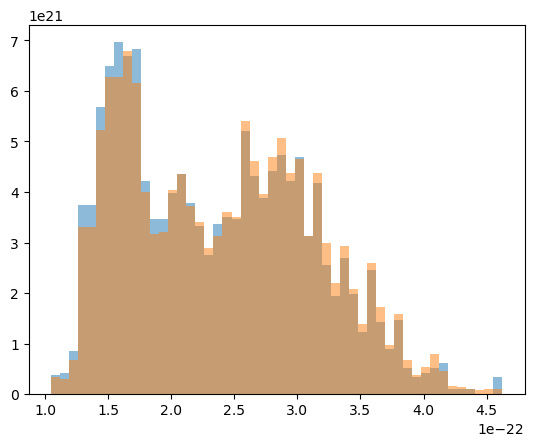

In [13]:
plt.hist(samples[:, 1], bins=50, density=True, alpha=0.5, label='Samples')
plt.hist(flow_samples[:, 1], bins=50, density=True, alpha=0.5, label='Flow Samples')

In [14]:
lp

Array([106.97912902, 105.493258  , 108.40740513, ..., 106.14899812,
       109.14155801, 107.13657838], dtype=float64)

In [15]:
flow.log_prob(jax.numpy.array(injection_params[1]))

Array(35.70535857, dtype=float64)

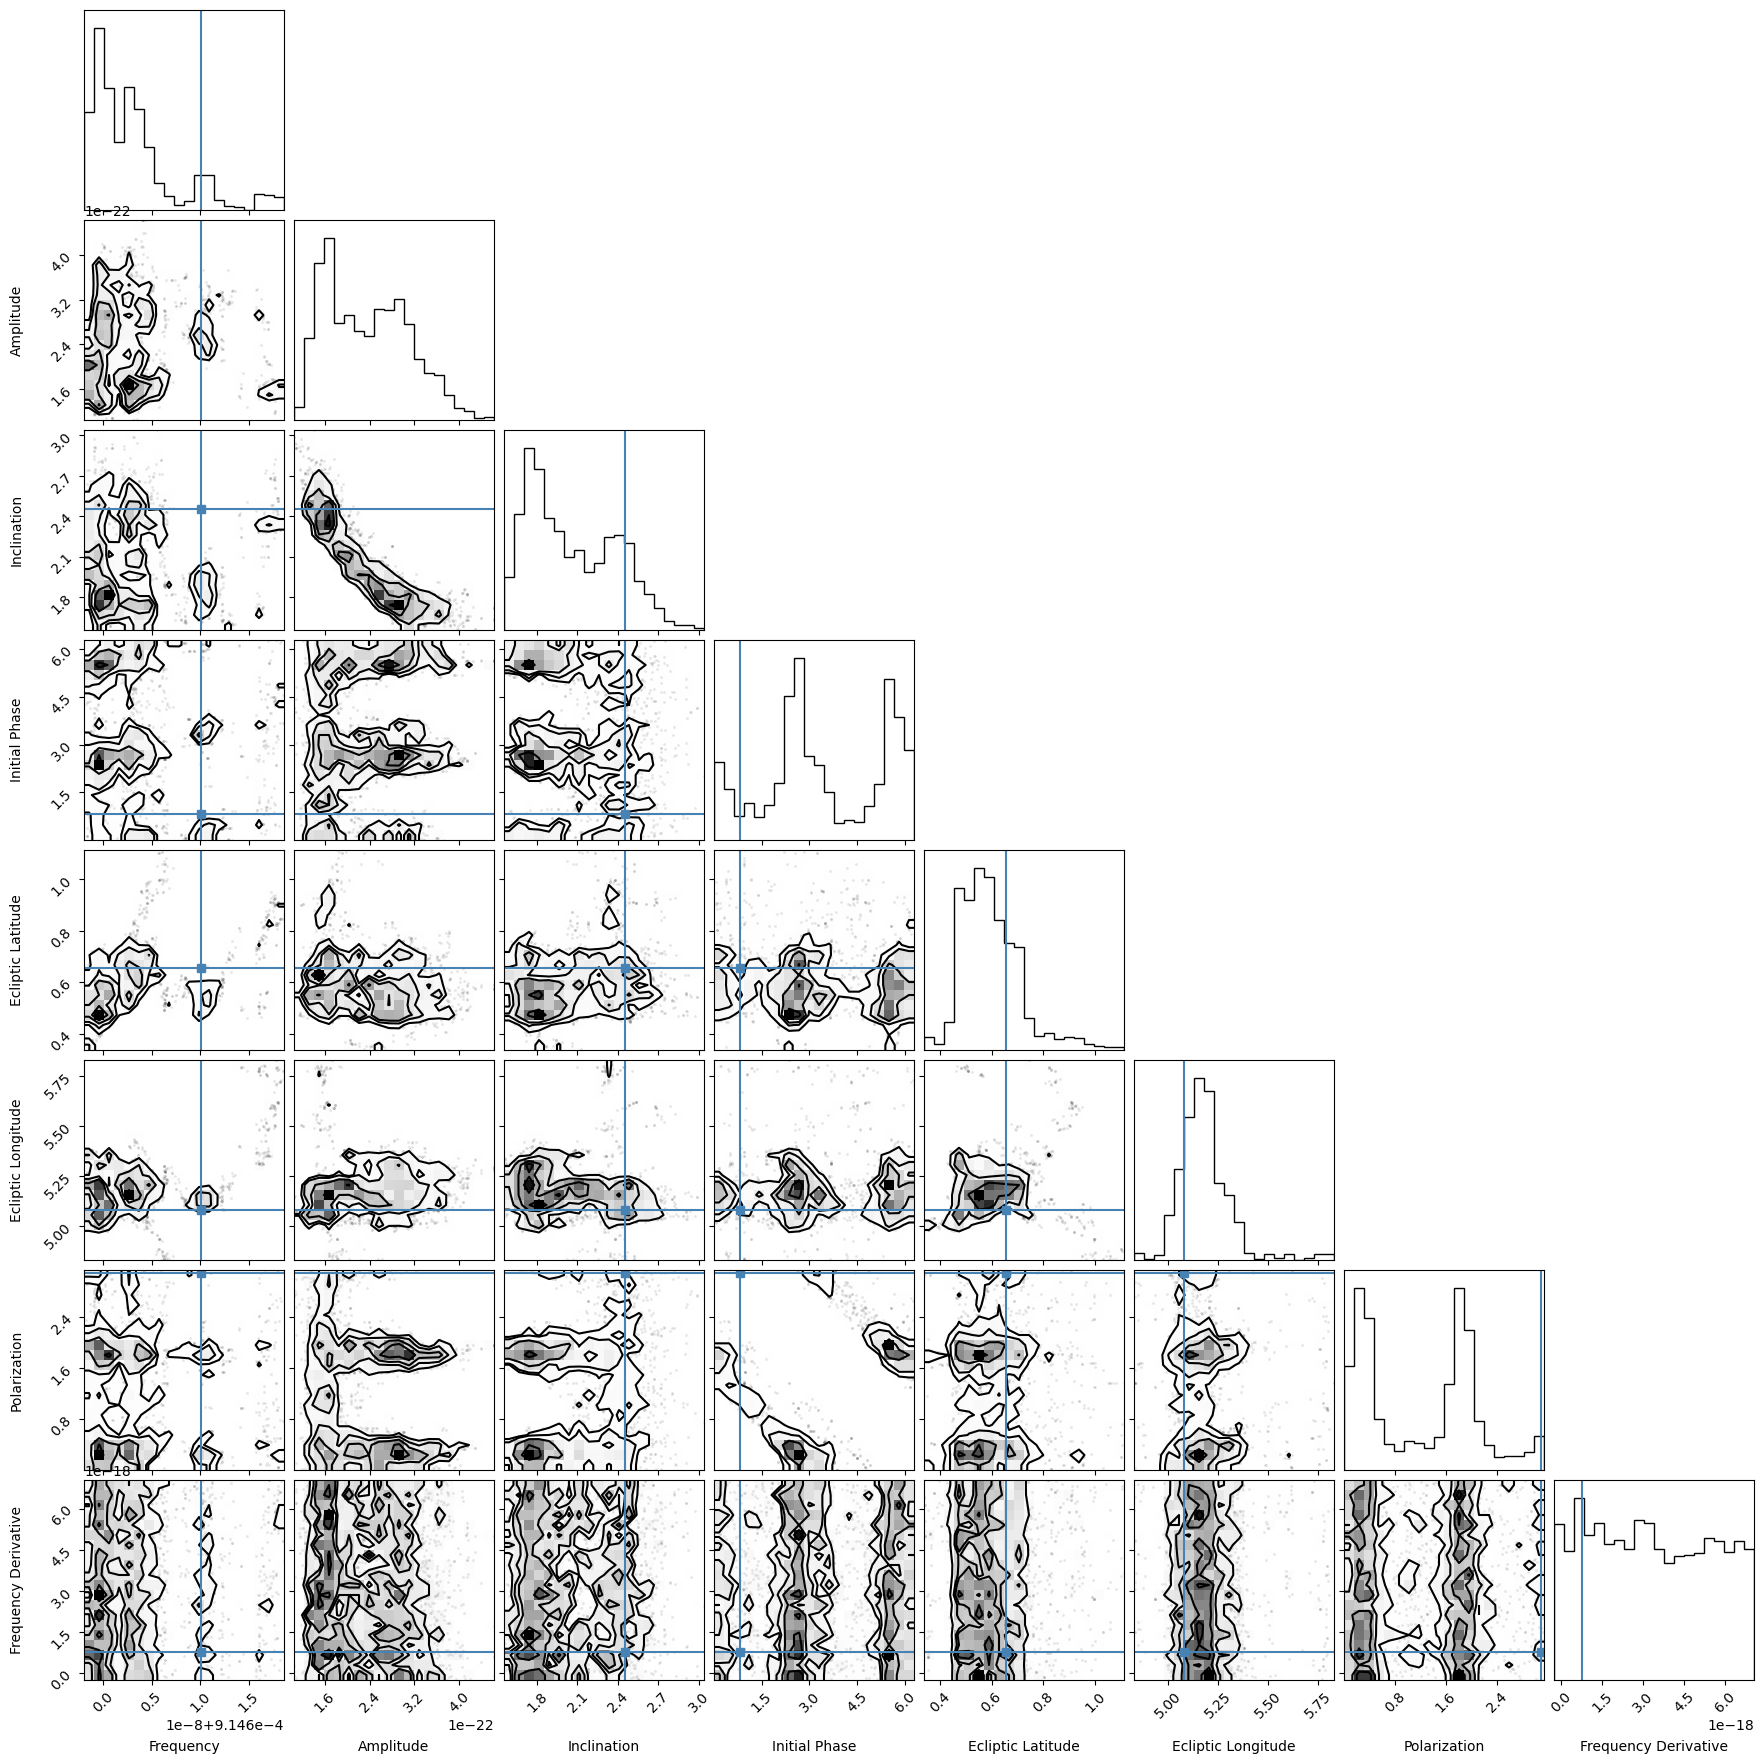

In [16]:
corner.corner(samples, labels=binary_parameters, truths=injection_params[1]);

In [17]:
samples[:, 1].min()

np.float64(1.04861359035e-22)

columns: ['Frequency', 'Amplitude', 'Inclination', 'Initial Phase', 'Ecliptic Latitude', 'Ecliptic Longitude', 'Polarization', 'Frequency Derivative']
injection[1] (all): [9.14610105e-04 2.92489066e-23 2.45373608e+00 8.18837623e-01
 6.55873818e-01 5.07694080e+00 3.09619336e+00 7.53584771e-19]
amplitude in injection[1]: 2.9248906610600424e-23
samples amp min/max: 1.04861359035e-22 4.62190925659e-22


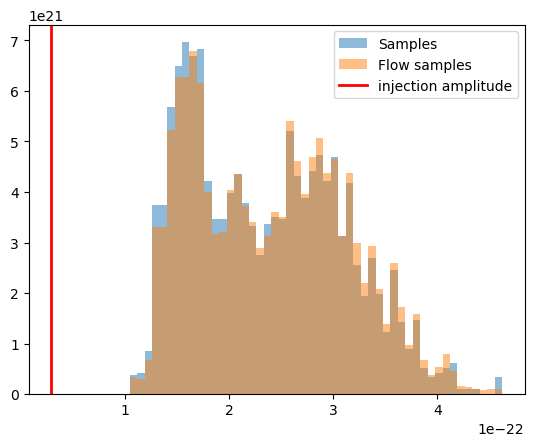

NameError: name 'sample_and_log_prob' is not defined

In [18]:
# 1) Confirm column ordering and the actual amplitude value
print("columns:", binary_parameters)
print("injection[1] (all):", injection_params[1])
print("amplitude in injection[1]:", injection_params[1, 1])

# 2) Compare empirical range of amplitude to injection
print("samples amp min/max:", samples[:,1].min(), samples[:,1].max())

# 3) Plot histogram with injection vertical line
plt.hist(samples[:,1], bins=50, density=True, alpha=0.5, label='Samples')
plt.hist(flow_samples[:,1], bins=50, density=True, alpha=0.5, label='Flow samples')
plt.axvline(injection_params[1,1], color='r', lw=2, label='injection amplitude')
plt.legend(); plt.show()

# 4) Compute injection log-prob and its percentile among generated log-probs
import jax, numpy as onp
inj_vec = jax.numpy.array(injection_params[1])   # or convert to whatever format flow.log_prob expects
inj_lp = float(flow.log_prob(inj_vec))
# get generated log-probs (use same helper you used earlier)
gen_samples, gen_logp = sample_and_log_prob(flow, n_samples=100_000)
perc = (gen_logp >= inj_lp).mean()
print("injection log-prob:", inj_lp)
print("percentile among generated samples (HDR fraction):", float(perc))

In [ ]:
# diagnostics for HDR clipping
import jax.numpy as jnp

# 1) injection log-prob and generated log-probs
inj_vec = jax.numpy.array(injection_params[1])
inj_lp = float(flow.log_prob(inj_vec))
gen_samples, gen_logp = sample_and_log_prob(flow, n_samples=200_000)   # increase N
frac = (gen_logp >= inj_lp).mean()
print("inj_lp:", inj_lp)
print("HDR fraction (N=200k):", float(frac))
print("counts >= inj_lp:", int((gen_logp >= inj_lp).sum()), " / ", len(gen_logp))

# 2) tail quantiles of gen_logp
for p in [90,95,99,99.7,99.72,99.73,99.8,99.9,99.99]:
    print(f"p{p}:", np.percentile(np.array(gen_logp), p))

# 3) check for duplicate generated values at the marginal of interest (Amplitude is col index 1)
col = 1
vals = np.array(gen_samples[:, col])
uniq, counts = np.unique(vals, return_counts=True)
top = uniq[np.argsort(counts)[-10:]]   # values with largest counts (if any)
print("unique count:", len(uniq))
print("top repeated values (value:count):", [(v,int(c)) for v,c in zip(uniq[np.argsort(counts)[-10:]], np.sort(counts)[-10:])])

# 4) test quantile_fn behavior near 1.0 (use the empirical marginal object if available)
# If you have the EmpiricalMarginalToGaussian instance (em) for that marginal:
try:
    u_tests = jnp.array([0.99723, 0.999, 0.9999, 1.0, 1.0 - 1e-12])
    print("quantiles at u:", em.quantile_fn(u_tests))
    print("cdf at x near data_max:", em.cdf_fn(em.data_max - 1e-12), em.cdf_fn(em.data_max))
    print("raw_cdf last entries:", np.array(em.raw_cdf[-5:]))
    print("x_grid last entries:", np.array(em.x_grid[-5:]))
except NameError:
    print("Empirical marginal object 'em' not available; print raw_cdf/x_grid from your transform instead.")